# **模块**: 单变量统计过程监控
## **课程**: EWMA控制图的工业应用
### *主题*:  基于EWMA控制图的曝气池监控

In [1]:
# 导入所需包
import numpy as np
import matplotlib.pyplot as plt
# 中文显示设置
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


In [2]:
# ==================================================================================
#                        读取并探索数据集
# ==================================================================================

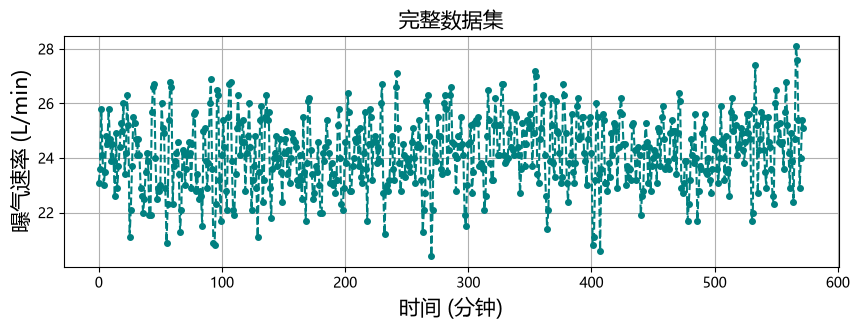

In [6]:
# 读取数据
data = np.loadtxt('aeration-rate.csv', skiprows=1)

# 绘图
plt.figure(figsize=(10,3))
plt.plot(data,'--',marker='o', markersize=4, color='teal')
plt.xlabel('时间 (分钟)', fontsize=15), plt.ylabel('曝气速率 (L/min)', fontsize=15)
plt.title('完整数据集', fontsize=15)
plt.grid()
plt.show()

In [7]:
# ==================================================================================
#                                    模型训练
# ==================================================================================

> ##### 将使用前200个样本作为NOC数据估计EWMA控制图参数：信号的均值(mu)、标准差(sigma)以及控制限

In [8]:
# 获取NOC数据
N = 200
x_faultFree = data[:N]

In [9]:
# 估计EWMA模型参数
mu, sigma = np.mean(x_faultFree), np.std(x_faultFree)
lambda_value = 0.2
LCL = mu - 3*sigma*np.sqrt(lambda_value/(2-lambda_value))
UCL = mu + 3*sigma*np.sqrt(lambda_value/(2-lambda_value))

print(f'EWMA 控制图控制限：UCL={UCL}，LCL={LCL}')

EWMA 控制图控制限：UCL=25.308735678201607，LCL=22.581264321798393


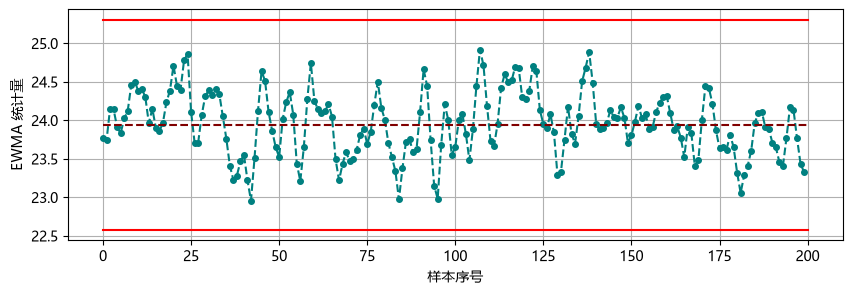

In [10]:
# 计算NOC数据的EWMA统计量
z = np.zeros((N,))
z0 = mu

for i in range(N):
    if i==0:
        z[i] = lambda_value*x_faultFree[i] + (1-lambda_value)*z0
    else:
        z[i] = lambda_value*x_faultFree[i] + (1-lambda_value)*z[i-1]

# 绘制NOC数据控制图
plt.figure(figsize=(10,3))
plt.plot(z,'--',marker='o', markersize=4, color='teal')
plt.plot([0,N],[LCL,LCL], color='red'), plt.plot([0,N],[UCL,UCL], color='red')
plt.plot([0,N],[mu,mu], '--', color='maroon')
plt.xlabel('样本序号'), plt.ylabel('EWMA 统计量')
plt.grid()
plt.show()

In [11]:
# ==================================================================================
#               获取测试样本并绘制在控制图上
# ==================================================================================

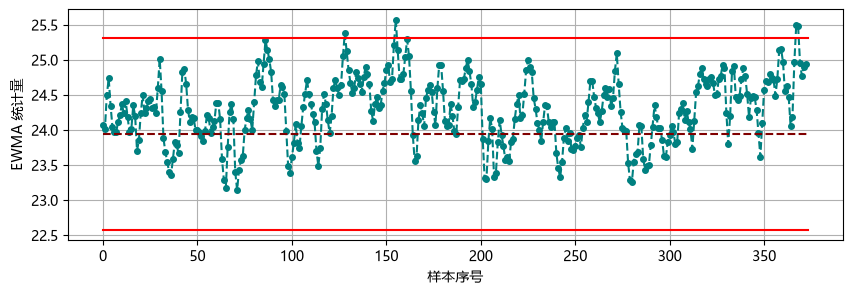

In [12]:
# 测试数据
x_test = data[200:]
N_test = len(x_test)

# 故障数据的EWMA统计量
z_test = np.zeros((N_test,))

for i in range(N_test):
    if i==0:
        z_test[i] = lambda_value*x_test[i] + (1-lambda_value)*z0
    else:
        z_test[i] = lambda_value*x_test[i] + (1-lambda_value)*z_test[i-1]

# 测试数据的控制图
plt.figure(figsize=(10,3))
plt.plot(z_test,'--',marker='o', markersize=4, color='teal')
plt.plot([0,N_test],[LCL,LCL], color='red'), plt.plot([0,N_test],[UCL,UCL], color='red')
plt.plot([0,N_test],[mu,mu], '--', color='maroon')
plt.xlabel('样本序号'), plt.ylabel('EWMA 统计量')
plt.grid()
plt.show()